# Figure S14: Winner-Take-All Maximum Quality-Effect Heatmap

Large heatmap across all 33 microstructural metrics and bundles. Cell fill shows the maximum quality effect across all IQMs, and overlaid symbols denote the IQM family of the winning quality metric.


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS14/S14_max_quality_effect_winner_take_all_heatmap.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS14/S14_max_quality_effect_winner_take_all_heatmap.png



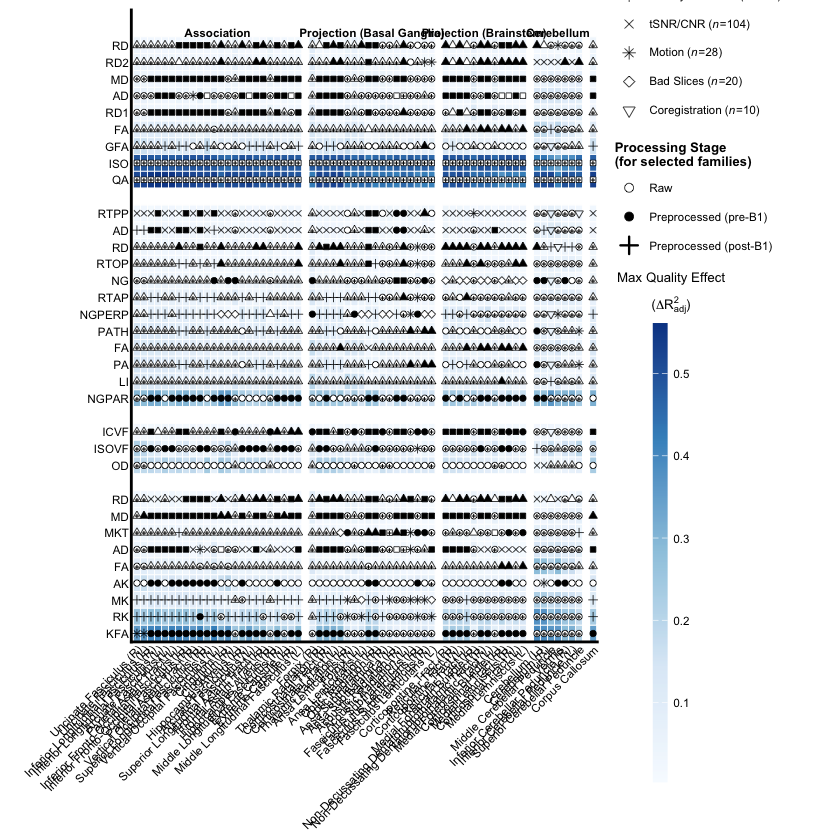

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(grid)
})

config_candidates <- c(
  Sys.getenv("CONFIG_PATH", unset = ""),
  fs::path(".", "config.json"),
  fs::path("..", "config.json"),
  fs::path("..", "..", "config.json")
)
config_candidates <- normalizePath(unique(config_candidates[nzchar(config_candidates)]), winslash = "/", mustWork = FALSE)
config_path <- config_candidates[file.exists(config_candidates)][1]
if (is.na(config_path) || !nzchar(config_path)) {
  stop("Could not locate config.json. Set CONFIG_PATH or run from within the project tree.")
}

config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s14_dir <- fs::path(project_root, "figures", "Supplement", "FigureS14")
fs::dir_create(figure_s14_dir, recurse = TRUE)

quality_effect_file <- fs::path(project_root, "data", "quality_effects", "quality_effects_all_outputs.rds")
if (!file.exists(quality_effect_file)) {
  stop("Missing assembled quality-effect file: ", quality_effect_file)
}

df_quality_all <- readRDS(quality_effect_file)
required_cols <- c(
  "bundle", "bundle_category", "metric", "qc_metric", "source",
  "output_type", "qc_effect_size"
)
missing_cols <- setdiff(required_cols, names(df_quality_all))
if (length(missing_cols) > 0) {
  stop("Assembled quality-effect data missing required columns: ",
       paste(missing_cols, collapse = ", "))
}

metrics_keep <- trimws(as.character(config$microstructural_metrics))
if (length(metrics_keep) != 33) {
  message("[FigureS14] config$microstructural_metrics has ", length(metrics_keep),
          " metrics (expected 33). Continuing with config-defined list.")
}
software_order <- c("DIPY", "AMICO", "TORTOISE", "DSI Studio")
category_order <- c(
  "Association",
  "Projection (Basal Ganglia)",
  "Projection (Brainstem)",
  "Cerebellum",
  "Commissure"
)

iqm_metrics <- c(
  "raw_neighbor_corr", "raw_masked_neighbor_corr",
  "raw_dwi_contrast", "raw_num_bad_slices",
  "raw_coherence_index", "raw_incoherence_index",
  "t1_neighbor_corr", "t1_masked_neighbor_corr",
  "t1_dwi_contrast", "t1_num_bad_slices",
  "t1_coherence_index", "t1_incoherence_index",
  "t1post_neighbor_corr", "t1post_masked_neighbor_corr",
  "t1post_dwi_contrast", "t1post_num_bad_slices",
  "t1post_coherence_index", "t1post_incoherence_index",
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation", "t1_dice_distance",
  "CNR0_mean", "CNR1_mean", "CNR2_mean", "CNR3_mean", "CNR4_mean",
  "CNR0_median", "CNR1_median", "CNR2_median", "CNR3_median", "CNR4_median",
  "CNR0_standard_deviation", "CNR1_standard_deviation", "CNR2_standard_deviation",
  "CNR3_standard_deviation", "CNR4_standard_deviation", "qc_prediction"
)

motion_iqms <- c(
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation"
)

classify_family <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier")
  if (iqm == "t1_dice_distance") return("Coregistration")
  if (iqm %in% motion_iqms) return("Motion")
  if (str_detect(iqm, "^CNR[0-4]_")) return("tSNR/CNR")
  if (str_detect(iqm, "neighbor_corr")) return("dMRI Neighboring Corr.")
  if (str_detect(iqm, "dwi_contrast")) return("dMRI Contrast")
  if (str_detect(iqm, "num_bad_slices")) return("Bad Slices")
  if (str_detect(iqm, "coherence_index") || str_detect(iqm, "incoherence_index")) return("Coherence/Incoherence")
  "Other"
}

family_order <- c(
  "dMRI Neighboring Corr.",
  "dMRI Contrast",
  "Coherence/Incoherence",
  "Bad Slices",
  "Motion",
  "tSNR/CNR",
  "Coregistration",
  "Quality Classifier"
)

family_shapes <- c(
  "dMRI Neighboring Corr." = 21,
  "dMRI Contrast" = 24,
  "Coherence/Incoherence" = 22,
  "Bad Slices" = 23,
  "Motion" = 8,
  "tSNR/CNR" = 4,
  "Coregistration" = 6,
  "Quality Classifier" = 3
)

stage_families <- c(
  "dMRI Neighboring Corr.",
  "dMRI Contrast",
  "Bad Slices",
  "Coherence/Incoherence"
)

classify_stage <- function(iqm) {
  if (str_starts(iqm, "raw_")) return("Raw")
  if (str_starts(iqm, "t1_")) return("Preprocessed (pre-B1)")
  if (str_starts(iqm, "t1post_")) return("Preprocessed (post-B1)")
  NA_character_
}
stage_order <- c("Raw", "Preprocessed (pre-B1)", "Preprocessed (post-B1)")
stage_labels_expr <- setNames(
  list(
    bquote(Raw),
    bquote("Preprocessed (pre-" * italic(B) * "1)"),
    bquote("Preprocessed (post-" * italic(B) * "1)")
  ),
  stage_order
)

metric_display <- setNames(
  ifelse(
    str_detect(metrics_keep, "_"),
    str_to_upper(str_remove(metrics_keep, "^[^_]+_")),
    str_to_upper(metrics_keep)
  ),
  metrics_keep
)

df_heat <- df_quality_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    source == "harmonized",
    metric %in% metrics_keep,
    qc_metric %in% iqm_metrics,
    !is.na(bundle), !is.na(bundle_category), !is.na(qc_effect_size)
  ) %>%
  mutate(
    software = case_when(
      str_starts(metric, "DKI_") ~ "DIPY",
      str_starts(metric, "NODDI_") ~ "AMICO",
      str_starts(metric, "MAPMRI_") ~ "TORTOISE",
      str_starts(metric, "GQI_") ~ "DSI Studio",
      TRUE ~ "Other"
    ),
    bundle_clean = bundle,
    bundle_category = case_when(
      bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
      bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
      TRUE ~ bundle_category
    ),
    bundle_clean = bundle_clean %>%
      str_replace("FrontoOccipital", "Fronto-Occipital") %>%
      str_replace("NonDecussating", "Non-Decussating") %>%
      str_replace("L$", " (L)") %>%
      str_replace("R$", " (R)") %>%
      str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
  ) %>%
  filter(software %in% software_order)

if (nrow(df_heat) == 0) stop("No rows for FigureS14 heatmap after filtering.")

df_wta <- df_heat %>%
  arrange(bundle_clean, metric, desc(qc_effect_size), qc_metric) %>%
  group_by(bundle_clean, bundle_category, metric, software) %>%
  slice(1) %>%
  ungroup() %>%
  mutate(
    iqm_family = vapply(qc_metric, classify_family, character(1)),
    iqm_stage = vapply(qc_metric, classify_stage, character(1)),
    iqm_stage = if_else(iqm_family %in% stage_families, iqm_stage, NA_character_),
    iqm_family = factor(iqm_family, levels = family_order)
  )

family_counts <- df_wta %>%
  filter(!is.na(iqm_family)) %>%
  count(iqm_family, name = "n") %>%
  mutate(iqm_family = as.character(iqm_family)) %>%
  arrange(desc(n), iqm_family)

family_order_plot <- family_counts$iqm_family
family_labels <- setNames(
  paste0(family_order_plot, " (n=", family_counts$n, ")"),
  family_order_plot
)
family_labels_expr <- setNames(
  lapply(seq_along(family_order_plot), function(i) {
    bquote(.(family_order_plot[i]) ~ "(" * italic(n) * "=" * .(family_counts$n[i]) * ")")
  }),
  family_order_plot
)

metric_rank <- df_wta %>%
  group_by(software, metric) %>%
  summarise(mean_effect = mean(qc_effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(software = factor(software, levels = software_order)) %>%
  arrange(software, desc(mean_effect), metric)

metric_levels <- c()
for (sw in software_order) {
  sw_metrics <- metric_rank %>% filter(software == sw) %>% pull(metric)
  if (length(sw_metrics) > 0) {
    metric_levels <- c(metric_levels, sw_metrics, paste0("spacer_", sw))
  }
}
metric_levels <- metric_levels[!grepl("^spacer_DSI Studio$", metric_levels)]

bundle_rank <- df_wta %>%
  group_by(bundle_category, bundle_clean) %>%
  summarise(mean_effect = mean(qc_effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(bundle_category = factor(bundle_category, levels = category_order)) %>%
  arrange(bundle_category, desc(mean_effect), bundle_clean)

bundle_levels <- c()
for (cat in category_order) {
  cat_bundles <- bundle_rank %>% filter(bundle_category == cat) %>% pull(bundle_clean)
  if (length(cat_bundles) > 0) {
    bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
  }
}
bundle_levels <- bundle_levels[!grepl("^spacer_Commissure$", bundle_levels)]

bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
cat_positions <- bundle_rank %>%
  group_by(bundle_category) %>%
  summarise(
    xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmid = mean(c(xmin, xmax)),
    .groups = "drop"
  ) %>%
  filter(bundle_category != "Commissure")

spacer_rows <- expand.grid(
  bundle_clean = bundle_levels,
  metric = metric_levels[grepl("^spacer_", metric_levels)],
  stringsAsFactors = FALSE
) %>%
  mutate(
    qc_effect_size = NA_real_,
    iqm_stage = NA_character_,
    iqm_family = factor(NA_character_, levels = family_order)
  )

spacer_cols <- expand.grid(
  bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
  metric = metric_levels,
  stringsAsFactors = FALSE
) %>%
  mutate(
    qc_effect_size = NA_real_,
    iqm_stage = NA_character_,
    iqm_family = factor(NA_character_, levels = family_order)
  )

df_plot <- bind_rows(
  df_wta %>% select(bundle_clean, metric, qc_effect_size, iqm_family, iqm_stage),
  spacer_rows,
  spacer_cols
) %>%
  distinct(bundle_clean, metric, .keep_all = TRUE) %>%
  mutate(
    bundle_clean = factor(bundle_clean, levels = bundle_levels),
    metric = factor(metric, levels = metric_levels)
  )

x_labels <- levels(df_plot$bundle_clean)
x_labels[grepl("^spacer_", x_labels)] <- ""

y_levels <- levels(df_plot$metric)
y_labels <- ifelse(
  grepl("^spacer_", y_levels),
  "",
  unname(metric_display[y_levels])
)
y_labels[is.na(y_labels)] <- y_levels[is.na(y_labels)]

df_symbol <- df_plot %>% filter(!is.na(iqm_family), !is.na(qc_effect_size))
df_symbol_nonstage <- df_symbol %>% filter(is.na(iqm_stage))
df_symbol_raw <- df_symbol %>% filter(iqm_stage == "Raw")
df_symbol_pre <- df_symbol %>% filter(iqm_stage == "Preprocessed (pre-B1)")
df_symbol_post <- df_symbol %>% filter(iqm_stage == "Preprocessed (post-B1)")

stage_legend_df <- tibble(
  bundle_clean = factor(rep(levels(df_plot$bundle_clean)[1], length(stage_order)), levels = levels(df_plot$bundle_clean)),
  metric = factor(rep(levels(df_plot$metric)[1], length(stage_order)), levels = levels(df_plot$metric)),
  iqm_stage = factor(stage_order, levels = stage_order)
)

p_s14 <- ggplot(df_plot, aes(x = bundle_clean, y = metric, fill = qc_effect_size)) +
  geom_tile(color = "white", linewidth = 0.25) +
  geom_point(
    data = df_symbol_nonstage,
    aes(shape = iqm_family),
    inherit.aes = TRUE,
    color = "black",
    fill = "white",
    size = 1.55,
    stroke = 0.32
  ) +
  geom_point(
    data = df_symbol_raw,
    aes(shape = iqm_family),
    inherit.aes = TRUE,
    color = "black",
    fill = "white",
    size = 1.55,
    stroke = 0.32
  ) +
  geom_point(
    data = df_symbol_pre,
    aes(shape = iqm_family),
    inherit.aes = TRUE,
    color = "black",
    fill = "white",
    size = 1.55,
    stroke = 0.32
  ) +
  geom_text(
    data = df_symbol_pre,
    aes(label = "+"),
    inherit.aes = TRUE,
    color = "black",
    size = 5 / .pt,
    family = font_family_use,
    fontface = "bold"
  ) +
  geom_point(
    data = df_symbol_post,
    aes(shape = iqm_family),
    inherit.aes = TRUE,
    color = "black",
    fill = "black",
    size = 1.55,
    stroke = 0.32
  ) +
  geom_point(
    data = stage_legend_df,
    aes(x = bundle_clean, y = metric, color = iqm_stage),
    inherit.aes = FALSE,
    alpha = 0,
    size = 0.01
  ) +
  scale_fill_gradientn(
    colours = c("#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#084594"),
    na.value = "white",
    name = expression(atop("Max Quality Effect", "(" * Delta * R[adj]^2 * ")"))
  ) +
  scale_shape_manual(
    values = family_shapes[family_order_plot],
    breaks = family_order_plot,
    labels = family_labels_expr[family_order_plot],
    drop = TRUE,
    name = "Winning IQM Family"
  ) +
  scale_color_manual(
    values = c("Raw" = "black", "Preprocessed (pre-B1)" = "black", "Preprocessed (post-B1)" = "black"),
    breaks = stage_order,
    labels = stage_labels_expr[stage_order],
    drop = FALSE,
    name = "Processing Stage\n(for selected families)"
  ) +
  guides(
    shape = guide_legend(order = 1, override.aes = list(size = 2.3, fill = "white", color = "black")),
    color = guide_legend(
      order = 2,
      override.aes = list(
        shape = c(21, 10, 21),
        fill = c("white", NA, "black"),
        color = "black",
        size = c(2.3, 2.8, 2.3),
        stroke = c(0.32, 1.0, 0.32),
        alpha = 1
      )
    ),
    fill = guide_colorbar(
      order = 3,
      title.position = "top",
      title.hjust = 0.5,
      theme = theme(legend.margin = margin(l = 5, r = 0, t = 0, b = 0)),
      barheight = grid::unit(length(metric_levels[!grepl("^spacer_", metric_levels)]) * 0.58, "lines"),
      barwidth = grid::unit(0.62, "lines")
    )
  ) +
  scale_x_discrete(labels = x_labels, expand = expansion(add = c(0.8, 0.6))) +
  scale_y_discrete(labels = y_labels, expand = expansion(mult = c(0, 0.06))) +
  coord_cartesian(clip = "off") +
  labs(x = NULL, y = NULL, title = NULL) +
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 7,
    axis_text_pt = 7,
    legend_title_pt = 8,
    legend_text_pt = 7,
    base_size_pt = 7
  ) +
  theme(
    text = element_text(family = font_family_use),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.margin = margin(t = 6, r = 10, b = 6, l = 48),
    legend.spacing.y = unit(2, "pt")
  )

y_top <- length(metric_levels) + 0.75
for (i in seq_len(nrow(cat_positions))) {
  p_s14 <- p_s14 + annotate(
    "text",
    x = cat_positions$xmid[i],
    y = y_top,
    label = cat_positions$bundle_category[i],
    family = font_family_use,
    size = 7 / .pt,
    fontface = "bold"
  )
}

p_s14

save_plot_outputs(
  plot_obj = p_s14,
  stub = "S14_max_quality_effect_winner_take_all_heatmap",
  out_dir = figure_s14_dir,
  width_in = 14,
  height_in = 11
)

